# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC; width: 100%;"><b>🏃Competiton : Predict Calorie Expenditure</b></div>

## URL : https://www.kaggle.com/code/leonchani/baseline-calorie-expenditure

# <b><span style="color: #FFFFFF; background-color: #7851A9; padding: 20px; font-size: 18px; border-left: 8px solid #C9A0DC">Importing Libraries</span></b>

In [1]:
# Table manipulation, calculating
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 100) # increase the maximum number of columns

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Learning
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor, Pool

# Saving model
import joblib

# Table directory
import shutil
import os

# Ignore all warnings
import warnings
warnings.simplefilter("ignore")

# <b><span style="color: #FFFFFF; background-color: #7851A9; padding: 20px; font-size: 18px; border-left: 8px solid #C9A0DC">Importing Datasets</span>

In [2]:
df_train = pd.read_csv('/kaggle/input/playground-series-s5e5/train.csv')
df_test = pd.read_csv('/kaggle/input/playground-series-s5e5/test.csv')

In [3]:
df_train

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
749995,749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0


In [4]:
df_test

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5
...,...,...,...,...,...,...,...,...
249995,999995,female,56,159.0,62.0,6.0,85.0,39.4
249996,999996,male,32,202.0,101.0,3.0,84.0,38.4
249997,999997,female,31,164.0,64.0,14.0,98.0,40.1
249998,999998,female,62,158.0,61.0,25.0,106.0,40.7


# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>📊EDA</b>

## Detail: https://www.kaggle.com/code/leonchani/eda-inspection-calorie-expenditure

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>🧹Preprocessing</b>

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>🤔Feature Engineering</b>

In [5]:
mapping = {'male': 1.5, 'female': 1.0}
df_train['Sex'] = df_train['Sex'].replace(mapping)
df_test['Sex']  = df_test['Sex'].replace(mapping)

In [6]:
def standardize_dataframe(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    Standardizes the columns of the specified DataFrame and returns the updated original DataFrame.
    
    Args:
        df (pd.DataFrame): The DataFrame to standardize.
        cols (list[str]): A list of column names to standardize.
    
    Returns:
        pd.DataFrame: The DataFrame with the specified columns standardized (modifies the original DataFrame).

    """
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    scaler.fit(df[cols])
    scaled_values = scaler.transform(df[cols])
    df[cols] = scaled_values

    return df

In [7]:
# columns_to_standardize = ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']
columns_to_drop = ['id', 'Calories']
columns_to_standardize = df_train.copy().drop(columns=columns_to_drop).columns

standardize_dataframe(df_train, columns_to_standardize)
standardize_dataframe(df_test, columns_to_standardize)

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,1.002251,0.233733,0.177381,0.418634,-1.007942,-0.897244,-0.303287
1,750001,1.002251,-1.018101,1.971171,1.563168,0.549109,0.584215,0.595940
2,750002,-0.997755,-0.820443,1.035280,0.704768,0.070016,0.690034,0.467479
3,750003,-0.997755,-0.161583,-0.212574,-0.153633,0.549109,1.219126,0.724402
4,750004,-0.997755,-0.754557,-0.134583,-0.582834,0.070016,-0.156514,0.595940
...,...,...,...,...,...,...,...,...
249995,999995,-0.997755,0.958478,-1.226455,-0.940500,-1.127716,-1.108881,-0.817131
249996,999996,1.002251,-0.622785,2.127152,1.849302,-1.487035,-1.214700,-2.101742
249997,999997,-0.997755,-0.688671,-0.836501,-0.797434,-0.169530,0.266760,0.082096
249998,999998,-0.997755,1.353794,-1.304446,-1.012034,1.147974,1.113308,0.852863


# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>🤖Modeling</b>

In [8]:
X = df_train.drop(columns=["id","Calories"])
# y = df_train["Calories"]
y = np.log1p(df_train["Calories"])

In [9]:
# Definition of the RMSLE evaluation function
def rmsle(y_true, y_pred):
    """Calculate the Root Mean Squared Logarithmic Error (RMSLE)"""
    y_pred_clipped = np.maximum(y_pred, 0)
    squared_log_error = (np.log1p(y_true) - np.log1p(y_pred_clipped)) ** 2
    return np.sqrt(np.mean(squared_log_error))

In [10]:
params_cb = {
    # Parameters that have a relatively small or indirect
    'objective': 'RMSE',
    'eval_metric': 'RMSE',  # Evaluation metrics during training (also using custom evaluation functions)
    'boosting_type': 'Plain', # 'Ordered', 'Plain'
    'verbose': 0,           # 0 ~ 1
    'random_seed': 42,
    'thread_count': -1,
    # 'task_type': 'GPU',
    
    # Parameters that are likely to have a large effect on the prediction
    'learning_rate': 0.05,  # 0.01 ~ 0.05 ~ 0.1
    'iterations': 2000,       # 100 ~ 500 ~ 1,000?
    'depth': 7,             # 3 ~ 7 ~ 10.
    'l2_leaf_reg': 3,       # L2 regularization factor (default: 3)
    'subsample': 0.8,       # 0.7 ~ 0.8 ~ 1.0.
    'colsample_bylevel': 0.8, # 0.7 ~ 0.8 ~ 1.0.
    'random_strength': 1,   # Randomness when splitting trees (default: 1)

    # Parameters that may have a moderate impact
    'min_data_in_leaf': 20, # 10 ~ 20 ~ 100?.
    'loss_function': 'RMSE' # explicitly specified
}

# K-fold cross-validation
NUM_SPLITS = 10
SEED = 42

kf = KFold(n_splits=NUM_SPLITS, shuffle=True, random_state=SEED)
rmsle_scores = []
models = []

for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold+1}")
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    train_pool = Pool(X_train, y_train)
    val_pool = Pool(X_val, y_val)

    model = CatBoostRegressor(**params_cb)
    model.fit(train_pool,
                 eval_set=val_pool,
                 early_stopping_rounds=100,
                 verbose=0)

    y_pred_val = model.predict(X_val)
    rmsle_val = rmsle(y_val, y_pred_val)
    rmsle_scores.append(rmsle_val)
    models.append(model)

# View cross-validation results
print("\nCatBoost Cross-validation RMSLE scores:", rmsle_scores)
print(f'Optimized Cross-validated RMSLE score (CatBoost): {np.mean(rmsle_scores):.3f} +/- {np.std(rmsle_scores):.3f}')
print(f'Max RMSLE score (CatBoost): {np.max(rmsle_scores):.3f}')
print(f'Min RMSLE score (CatBoost): {np.min(rmsle_scores):.3f}')

print("\nCatBoost Cross-validation RMSLE scores (expm1):", np.expm1(rmsle_scores))
print(f'Optimized Cross-validated RMSLE score (expm1, CatBoost): {np.mean(np.expm1(rmsle_scores)):.3f} +/- {np.std(np.expm1(rmsle_scores)):.3f}')
print(f'Max RMSLE score (expm1, CatBoost): {np.max(np.expm1(rmsle_scores)):.3f}')
print(f'Min RMSLE score (expm1, CatBoost): {np.min(np.expm1(rmsle_scores)):.3f}')

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10

CatBoost Cross-validation RMSLE scores: [0.01736142467524191, 0.01702599200386153, 0.017411163776470253, 0.016762059550018468, 0.0170134607750866, 0.01692632371594388, 0.016991086783639812, 0.017236561654415054, 0.016738674891873764, 0.016800988020878094]
Optimized Cross-validated RMSLE score (CatBoost): 0.017 +/- 0.000
Max RMSLE score (CatBoost): 0.017
Min RMSLE score (CatBoost): 0.017

CatBoost Cross-validation RMSLE scores (expm1): [0.01751301 0.01717176 0.01756362 0.01690333 0.01715901 0.01707039
 0.01713626 0.01738597 0.01687955 0.01694292]
Optimized Cross-validated RMSLE score (expm1, CatBoost): 0.017 +/- 0.000
Max RMSLE score (expm1, CatBoost): 0.018
Min RMSLE score (expm1, CatBoost): 0.017


## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>🔍Model Evaluation</b>

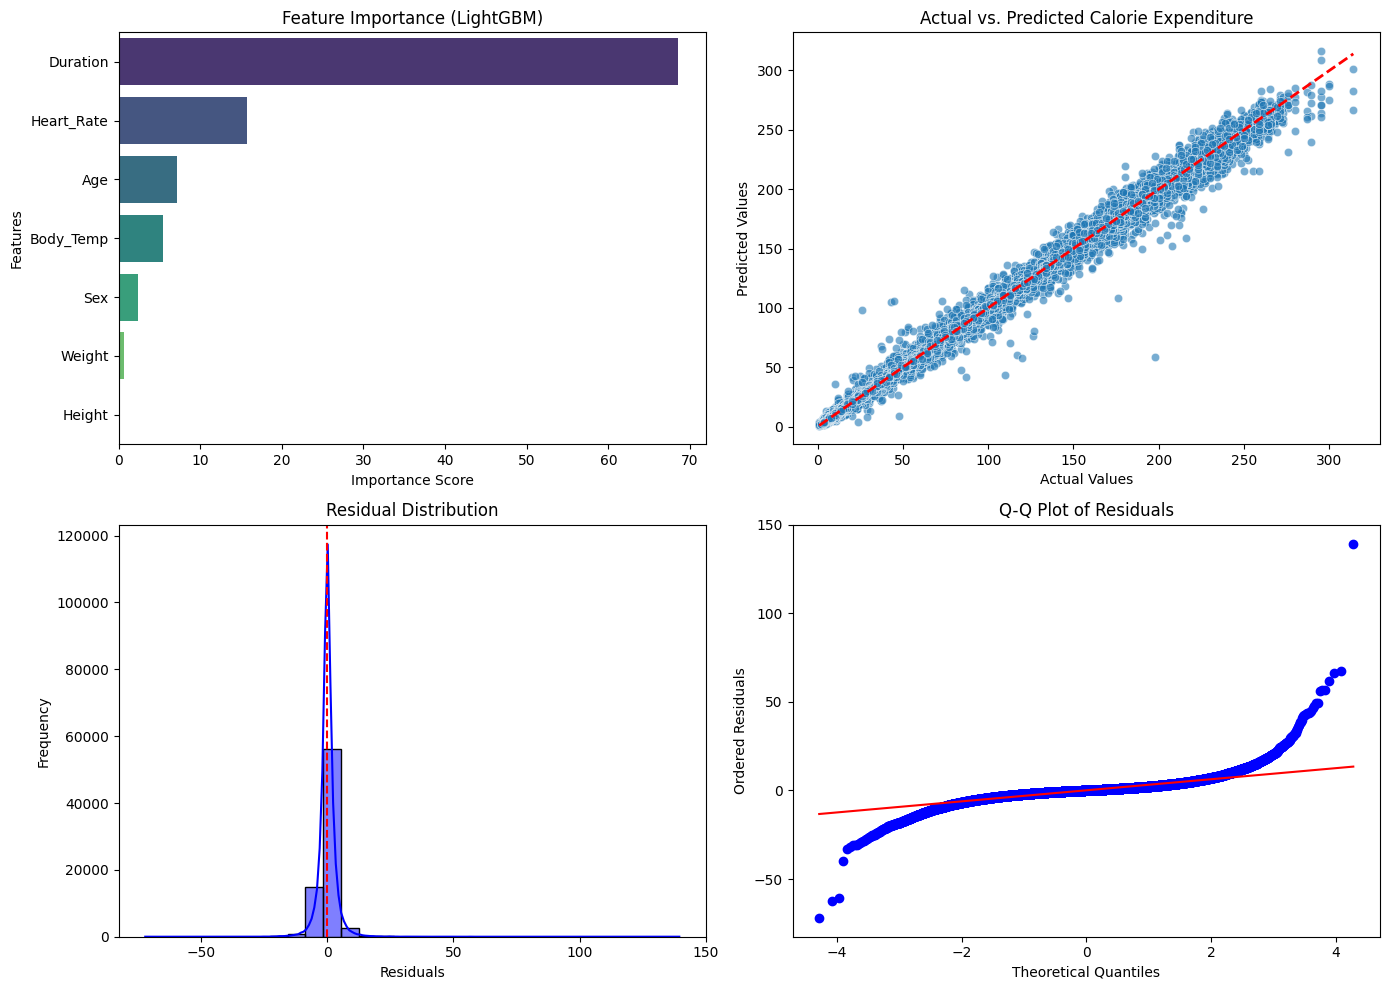

<Figure size 640x480 with 0 Axes>

In [11]:
# np.expm1(y_val) Version

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# feature_importance = model.feature_importances_
feature_importance = model.get_feature_importance()
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Feature Importance
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Feature Importance (LightGBM)")
axes[0, 0].set_xlabel("Importance Score")
axes[0, 0].set_ylabel("Features")

# Actual vs. Predicted
sns.scatterplot(x=np.expm1(y_val), y=np.expm1(y_pred_val), alpha=0.6, edgecolors="k", ax=axes[0, 1])
# sns.scatterplot(x=y_val, y=y_pred_val, alpha=0.6, edgecolors="k", ax=axes[0, 1])
axes[0, 1].plot([min(np.expm1(y_val)), max(np.expm1(y_val))], [min(np.expm1(y_val)), max(np.expm1(y_val))], '--r', linewidth=2) 
axes[0, 1].set_title("Actual vs. Predicted Calorie Expenditure")
axes[0, 1].set_xlabel("Actual Values")
axes[0, 1].set_ylabel("Predicted Values")

# Residual Distribution
residuals = np.expm1(y_val) - np.expm1(y_pred_val)
# residuals = y_val - y_pred_val
sns.histplot(residuals, bins=30, kde=True, color='blue', ax=axes[1, 0])
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_ylabel("Frequency")

# Q-Q Plot of Residuals
stats.probplot(residuals, plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals")
axes[1, 1].set_xlabel("Theoretical Quantiles")
axes[1, 1].set_ylabel("Ordered Residuals")

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

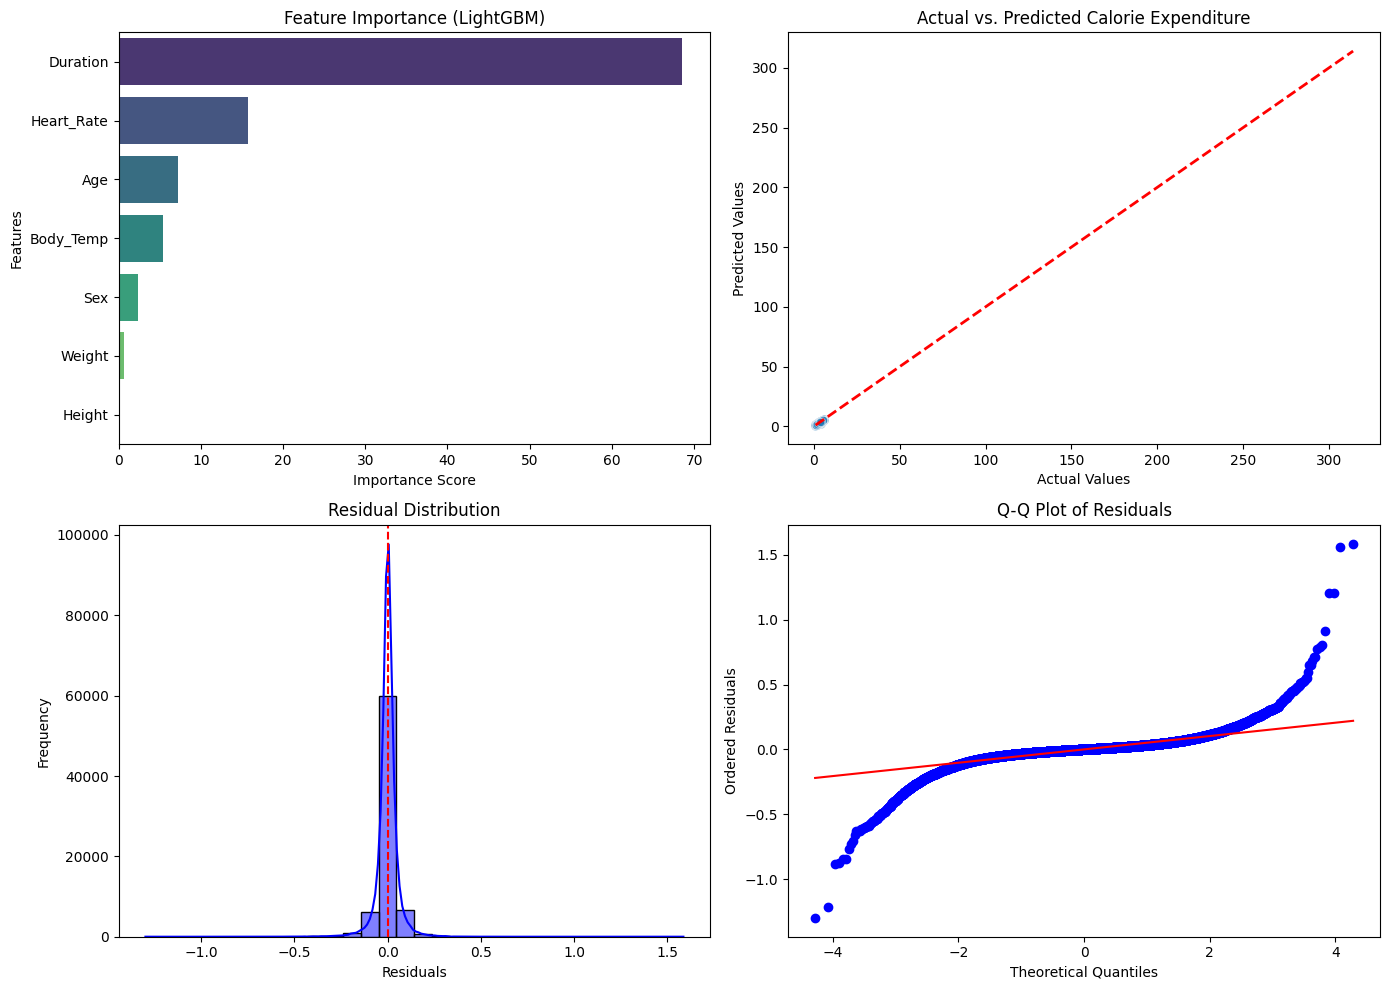

<Figure size 640x480 with 0 Axes>

In [12]:
# Original Version

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# feature_importance = model.feature_importances_
feature_importance = model.get_feature_importance()
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Feature Importance
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Feature Importance (LightGBM)")
axes[0, 0].set_xlabel("Importance Score")
axes[0, 0].set_ylabel("Features")

# Actual vs. Predicted
sns.scatterplot(x=y_val, y=y_pred_val, alpha=0.6, edgecolors="k", ax=axes[0, 1])
axes[0, 1].plot([min(np.expm1(y_val)), max(np.expm1(y_val))], [min(np.expm1(y_val)), max(np.expm1(y_val))], '--r', linewidth=2) 
axes[0, 1].set_title("Actual vs. Predicted Calorie Expenditure")
axes[0, 1].set_xlabel("Actual Values")
axes[0, 1].set_ylabel("Predicted Values")

# Residual Distribution
residuals = y_val - y_pred_val
sns.histplot(residuals, bins=30, kde=True, color='blue', ax=axes[1, 0])
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_ylabel("Frequency")

# Q-Q Plot of Residuals
stats.probplot(residuals, plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals")
axes[1, 1].set_xlabel("Theoretical Quantiles")
axes[1, 1].set_ylabel("Ordered Residuals")

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>🤔Select Features</b>

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>SHAP</b>

In [13]:
# import shap

# # LGBM SHAP values
# explainer_lgb = shap.TreeExplainer(model)
# shap_values_lgb = explainer_lgb.shap_values(X)

In [14]:
# shap.summary_plot(shap_values_lgb, X)

In [15]:
# # If shap_values_lgb is a list, convert it to a NumPy array
# if isinstance(shap_values_lgb, list):
#     shap_values_lgb = np.array(shap_values_lgb)

# # Handling the multiclass classification case
# if len(shap_values_lgb.shape) == 3:
#     shap_importance = np.abs(shap_values_lgb).mean(axis=1).mean(axis=0)
# # Handling binary classification cases
# else:
#     shap_importance = np.abs(shap_values_lgb).mean(axis=0)

# # Store in DataFrame
# df_importance = pd.DataFrame({
#     'feature': X.columns,
#     'shap_importance': shap_importance
# })

# # Sort by importance
# df_importance = df_importance.sort_values('shap_importance', ascending=False)

# # Show results
# display(df_importance)

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>🔍Prediction</b>

In [16]:
test_id = df_test["id"]
test = df_test.drop(columns=['id'])
submit_score = []

for fold_, model in enumerate(models):
    # predict test data
    pred_ = model.predict(test)
    submit_score.append(pred_)

# predict test data
pred = np.mean(submit_score, axis=0)

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>🔍Model Evaluation</b>

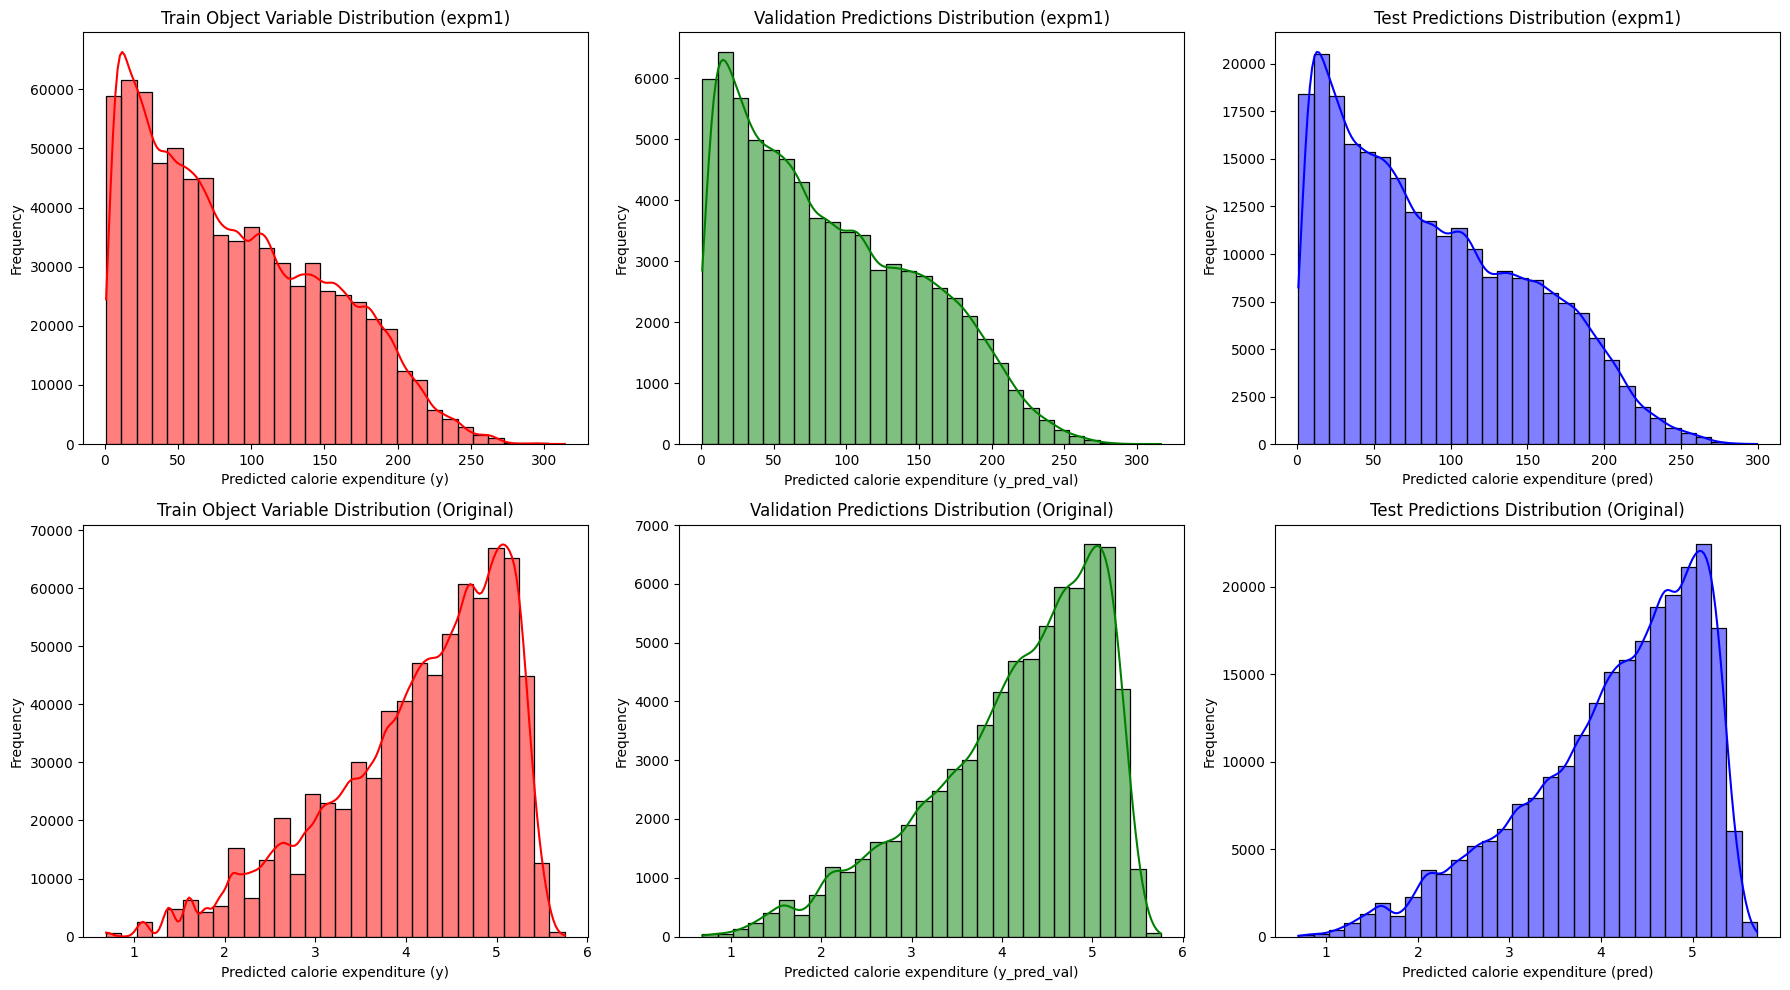

In [17]:
# Visualizing Distribution of target variable

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# np.expm1 Distribution
sns.histplot(np.expm1(y), bins=30, kde=True, color='red', ax=axes[0, 0])
axes[0, 0].set_title("Train Object Variable Distribution (expm1)")
axes[0, 0].set_xlabel("Predicted calorie expenditure (y)")
axes[0, 0].set_ylabel("Frequency")

sns.histplot(np.expm1(y_pred_val), bins=30, kde=True, color='green', ax=axes[0, 1])
axes[0, 1].set_title("Validation Predictions Distribution (expm1)")
axes[0, 1].set_xlabel("Predicted calorie expenditure (y_pred_val)")
axes[0, 1].set_ylabel("Frequency")

sns.histplot(np.expm1(pred), bins=30, kde=True, color='blue', ax=axes[0, 2])
axes[0, 2].set_title("Test Predictions Distribution (expm1)")
axes[0, 2].set_xlabel("Predicted calorie expenditure (pred)")
axes[0, 2].set_ylabel("Frequency")

# Original Distribution
sns.histplot(y, bins=30, kde=True, color='red', ax=axes[1, 0])
axes[1, 0].set_title("Train Object Variable Distribution (Original)")
axes[1, 0].set_xlabel("Predicted calorie expenditure (y)")
axes[1, 0].set_ylabel("Frequency")

sns.histplot(y_pred_val, bins=30, kde=True, color='green', ax=axes[1, 1])
axes[1, 1].set_title("Validation Predictions Distribution (Original)")
axes[1, 1].set_xlabel("Predicted calorie expenditure (y_pred_val)")
axes[1, 1].set_ylabel("Frequency")

sns.histplot(pred, bins=30, kde=True, color='blue', ax=axes[1, 2])
axes[1, 2].set_title("Test Predictions Distribution (Original)")
axes[1, 2].set_xlabel("Predicted calorie expenditure (pred)")
axes[1, 2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>📜Submission</b>

In [18]:
submission = pd.DataFrame({
    'id': test_id,
    'Calories': pred
})

submission['Calories'] = np.expm1(submission['Calories'])
submission['Calories'] = submission['Calories'].apply(lambda x: 0 if x < 0 else x)

# Save
submission.to_csv('submission.csv', index=False)

submission

,id,Calories
0,750000,27.216815
1,750001,108.144324
2,750002,86.865674
3,750003,125.907476
4,750004,76.046148
...,...,...
249995,999995,26.191374
249996,999996,9.475181
249997,999997,73.562641
249998,999998,168.790784


# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>🎁Saving model </b>

In [19]:
display(len(models))
display(models)

10

In [20]:
# Saving Models
joblib.dump(models,'CBT.joblib')

# Loading Models
light_gbm =joblib.load('CBT.joblib')
light_gbm

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>Check Libiraries Version</b></div>

In [21]:
!pip install watermark

In [22]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,aeppl,xarray

Last updated: Sat May 17 2025

Python implementation: CPython
Python version       : 3.11.11
IPython version      : 7.34.0

pytensor: 2.30.2
aeppl   : not installed
xarray  : 2025.1.2

seaborn   : 0.12.2
catboost  : 1.2.8
numpy     : 1.26.4
sklearn   : 1.2.2
joblib    : 1.5.0
matplotlib: 3.7.2
pandas    : 2.2.3
scipy     : 1.15.2

Watermark: 2.5.0



# Deleting catboost_info

In [23]:
import os
for dirname, _, filenames in os.walk('/kaggle/working/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/working/__notebook__.ipynb
/kaggle/working/submission.csv
/kaggle/working/CBT.joblib
/kaggle/working/catboost_info/test_error.tsv
/kaggle/working/catboost_info/catboost_training.json
/kaggle/working/catboost_info/learn_error.tsv
/kaggle/working/catboost_info/time_left.tsv
/kaggle/working/catboost_info/learn/events.out.tfevents
/kaggle/working/catboost_info/test/events.out.tfevents


In [24]:
catboost_info_path = '/kaggle/working/catboost_info'

if os.path.exists(catboost_info_path):
    try:
        shutil.rmtree(catboost_info_path)
        print(f"Deleting directory: {catboost_info_path}")
    except OSError as e:
        print(f"Failed deleting directory: {catboost_info_path} - {e}")
else:
    print(f"The specified directory does not exist.: {catboost_info_path}")

Deleting directory: /kaggle/working/catboost_info
